In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib
import os

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
master = pd.read_csv(
    "../data/processed/tourism_master_cleaned.csv"
)

print("Dataset shape:", master.shape)

display(master.head())

Dataset shape: (52930, 27)


,transactionid,userid,visityear,visitmonth,visitmode,attractionid,rating,user_continentid,user_regionid,user_countryid,user_cityid,user_cityname,user_city_countryid,user_country,user_country_regionid,user_region,user_region_continentid,user_continent,attractioncityid,attractiontypeid,attraction,attractionaddress,attractiontype,attraction_cityname,attraction_countryid,attraction_country,attraction_regionid
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,Guildford,109.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
1,8,7567,2022,10,4,640,5,2,8,48,464.0,Ontario,48.0,Canada,8,Northern America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
2,9,79069,2022,10,3,640,5,2,9,54,774.0,Brazil,51.0,Brazil,9,South America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
3,10,31019,2022,10,3,640,3,5,17,135,583.0,Zurich,48.0,Switzerland,17,Central Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
4,15,43611,2022,10,2,640,3,5,21,163,1396.0,Manchester,51.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1


In [4]:
mode_mapping = {
    1: "Business",
    2: "Couples",
    3: "Family",
    4: "Friends",
    5: "Solo"
}

master["visitmode_name"] = master["visitmode"].map(mode_mapping)

print(
    master["visitmode_name"].value_counts()
)

visitmode_name
Couples     21620
Family      15217
Friends     10945
Solo         4525
Business      623
Name: count, dtype: int64


In [5]:
print(
    "Missing VisitMode labels:",
    master["visitmode_name"].isna().sum()
)

Missing VisitMode labels: 0


In [6]:
class_distribution = (
    master["visitmode_name"]
    .value_counts()
    .reset_index()
)

class_distribution.columns = [
    "VisitMode",
    "Transactions"
]

class_distribution["Percentage"] = (
    class_distribution["Transactions"]
    / len(master)
    * 100
)

display(class_distribution)

,VisitMode,Transactions,Percentage
0,Couples,21620,40.846401
1,Family,15217,28.749292
2,Friends,10945,20.678254
3,Solo,4525,8.549027
4,Business,623,1.177026


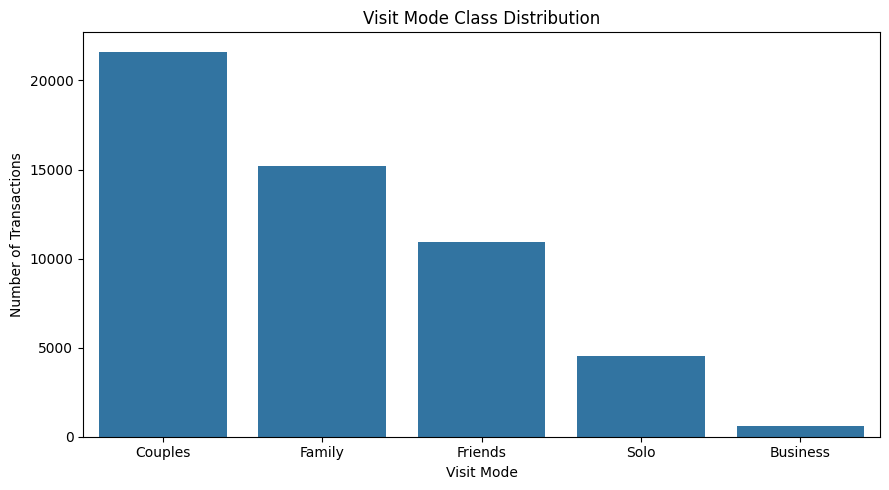

In [7]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=class_distribution,
    x="VisitMode",
    y="Transactions"
)

plt.title("Visit Mode Class Distribution")
plt.xlabel("Visit Mode")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [8]:
classification_features = [
    "visityear",
    "visitmonth",

    "user_continentid",
    "user_regionid",
    "user_countryid",
    "user_cityid",

    "attractionid",
    "attractioncityid",
    "attractiontypeid",
    "attraction_countryid",
    "attraction_regionid"
]

target = "visitmode_name"

X = master[classification_features].copy()
y = master[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (52930, 11)
y shape: (52930,)


In [9]:
categorical_features = [
    "user_continentid",
    "user_regionid",
    "user_countryid",
    "user_cityid",
    "attractionid",
    "attractioncityid",
    "attractiontypeid",
    "attraction_countryid",
    "attraction_regionid"
]

numeric_features = [
    "visityear",
    "visitmonth"
]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 42344
Testing samples : 10586


In [11]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
visitmode_name
Couples     0.408464
Family      0.287502
Friends     0.206783
Solo        0.085490
Business    0.011761
Name: proportion, dtype: float64

Testing distribution:
visitmode_name
Couples     0.408464
Family      0.287455
Friends     0.206783
Solo        0.085490
Business    0.011808
Name: proportion, dtype: float64


In [12]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [13]:
def evaluate_classifier(model, X_test, y_test):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [14]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [15]:
logistic_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
logistic_results = evaluate_classifier(
    logistic_model,
    X_test,
    y_test
)

print("Logistic Regression")
print("=" * 50)

for metric, value in logistic_results.items():
    print(
        f"{metric}: {value:.4f}"
    )

Logistic Regression
Accuracy: 0.3643
Precision: 0.4494
Recall: 0.3643
F1: 0.3939


In [17]:
rf_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced_subsample"
            )
        )
    ]
)

In [18]:
rf_classifier.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
rf_results = evaluate_classifier(
    rf_classifier,
    X_test,
    y_test
)

print("Random Forest")
print("=" * 50)

for metric, value in rf_results.items():
    print(
        f"{metric}: {value:.4f}"
    )

Random Forest
Accuracy: 0.4707
Precision: 0.4609
Recall: 0.4707
F1: 0.4623


In [20]:
classification_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_results
    },
    {
        "Model": "Random Forest",
        **rf_results
    }
])

classification_results = classification_results.sort_values(
    "F1",
    ascending=False
)

display(classification_results)

,Model,Accuracy,Precision,Recall,F1
1,Random Forest,0.470716,0.460892,0.470716,0.462310
0,Logistic Regression,0.364349,0.449367,0.364349,0.393934


In [21]:
logistic_predictions = logistic_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        logistic_predictions,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Business     0.0428    0.6000    0.0800       125
     Couples     0.5478    0.4531    0.4959      4324
      Family     0.5158    0.3746    0.4340      3043
     Friends     0.3044    0.1841    0.2294      2189
        Solo     0.1623    0.3094    0.2129       905

    accuracy                         0.3643     10586
   macro avg     0.3146    0.3842    0.2905     10586
weighted avg     0.4494    0.3643    0.3939     10586



In [22]:
rf_predictions = rf_classifier.predict(
    X_test
)

print(
    classification_report(
        y_test,
        rf_predictions,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Business     0.1988    0.2560    0.2238       125
     Couples     0.5221    0.6274    0.5700      4324
      Family     0.5016    0.4551    0.4773      3043
     Friends     0.3669    0.2915    0.3248      2189
        Solo     0.2949    0.2376    0.2632       905

    accuracy                         0.4707     10586
   macro avg     0.3769    0.3735    0.3718     10586
weighted avg     0.4609    0.4707    0.4623     10586



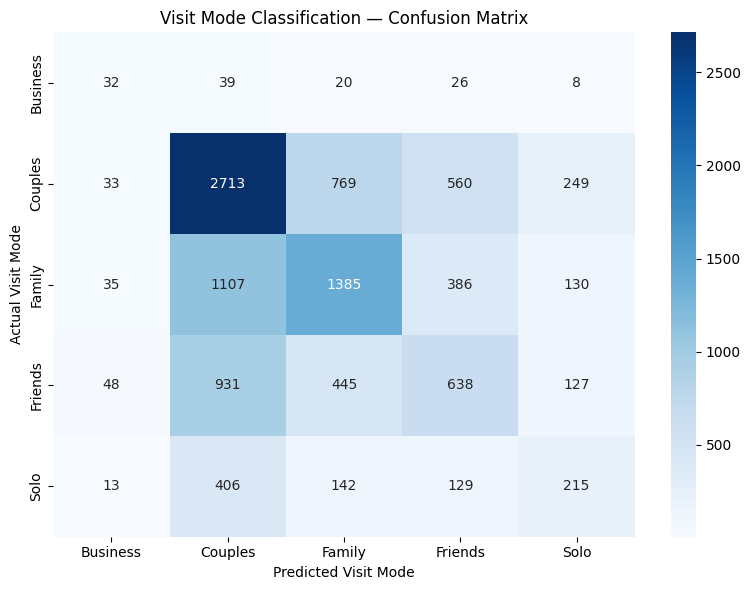

In [23]:
cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=[
        "Business",
        "Couples",
        "Family",
        "Friends",
        "Solo"
    ]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Business",
        "Couples",
        "Family",
        "Friends",
        "Solo"
    ],
    yticklabels=[
        "Business",
        "Couples",
        "Family",
        "Friends",
        "Solo"
    ]
)

plt.title("Visit Mode Classification — Confusion Matrix")
plt.xlabel("Predicted Visit Mode")
plt.ylabel("Actual Visit Mode")

plt.tight_layout()
plt.show()

In [24]:
rf_macro_f1 = f1_score(
    y_test,
    rf_predictions,
    average="macro",
    zero_division=0
)

rf_weighted_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

print("Random Forest Macro F1    :", round(rf_macro_f1, 4))
print("Random Forest Weighted F1 :", round(rf_weighted_f1, 4))

Random Forest Macro F1    : 0.3718
Random Forest Weighted F1 : 0.4623


In [25]:
classification_results.to_csv(
    "../reports/classification_baseline_results.csv",
    index=False
)

print("✅ Baseline classification results saved.")

✅ Baseline classification results saved.


In [26]:
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    print("❌ XGBoost is not installed.")

XGBoost version: 3.0.2


In [27]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape :", X_test_encoded.shape)

Encoded training shape: (42344, 5270)
Encoded testing shape : (10586, 5270)


In [28]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:")
print(label_encoder.classes_)

Classes:
['Business' 'Couples' 'Family' 'Friends' 'Solo']


In [29]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Sample weights created.")
print(
    "Minimum weight:",
    sample_weights.min()
)

print(
    "Maximum weight:",
    sample_weights.max()
)

Sample weights created.
Minimum weight: 0.48963922294172063
Maximum weight: 17.00562248995984


In [30]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=5,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [31]:
xgb_model.fit(
    X_train_encoded,
    y_train_encoded,
    sample_weight=sample_weights
)

print("✅ XGBoost training completed.")

✅ XGBoost training completed.


In [32]:
xgb_predictions_encoded = xgb_model.predict(
    X_test_encoded
)

xgb_predictions = label_encoder.inverse_transform(
    xgb_predictions_encoded.astype(int)
)

In [33]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

xgb_macro_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("XGBOOST CLASSIFICATION RESULTS")
print("=" * 60)

print("Accuracy        :", round(xgb_accuracy, 4))
print("Precision       :", round(xgb_precision, 4))
print("Recall          :", round(xgb_recall, 4))
print("Weighted F1     :", round(xgb_f1, 4))
print("Macro F1        :", round(xgb_macro_f1, 4))

XGBOOST CLASSIFICATION RESULTS
Accuracy        : 0.3887
Precision       : 0.4511
Recall          : 0.3887
Weighted F1     : 0.4048
Macro F1        : 0.2965


In [34]:
print(
    classification_report(
        y_test,
        xgb_predictions,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Business     0.0515    0.5920    0.0948       125
     Couples     0.5368    0.5042    0.5200      4324
      Family     0.5149    0.4249    0.4656      3043
     Friends     0.3353    0.1325    0.1899      2189
        Solo     0.1624    0.3072    0.2125       905

    accuracy                         0.3887     10586
   macro avg     0.3202    0.3921    0.2965     10586
weighted avg     0.4511    0.3887    0.4048     10586



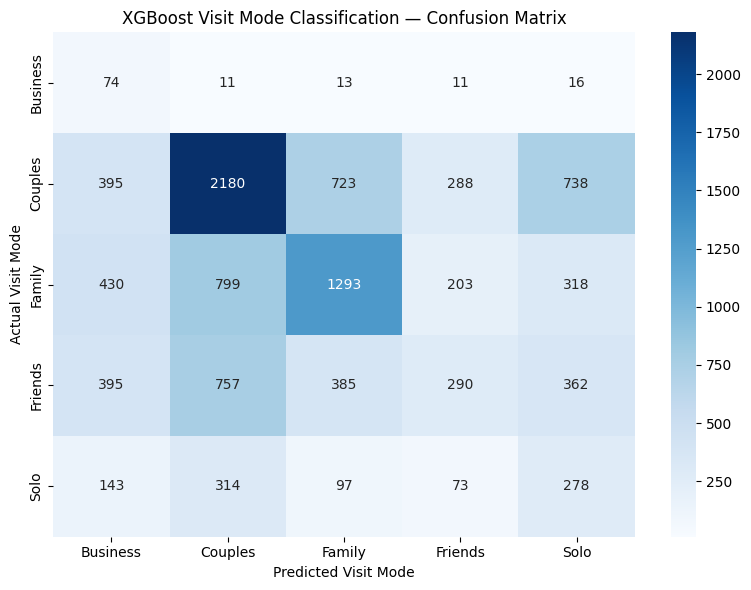

In [35]:
xgb_cm = confusion_matrix(
    y_test,
    xgb_predictions,
    labels=[
        "Business",
        "Couples",
        "Family",
        "Friends",
        "Solo"
    ]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Business",
        "Couples",
        "Family",
        "Friends",
        "Solo"
    ],
    yticklabels=[
        "Business",
        "Couples",
        "Family",
        "Friends",
        "Solo"
    ]
)

plt.title("XGBoost Visit Mode Classification — Confusion Matrix")
plt.xlabel("Predicted Visit Mode")
plt.ylabel("Actual Visit Mode")

plt.tight_layout()
plt.show()

In [36]:
classification_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_results
    },
    {
        "Model": "Random Forest",
        **rf_results
    },
    {
        "Model": "XGBoost",
        "Accuracy": xgb_accuracy,
        "Precision": xgb_precision,
        "Recall": xgb_recall,
        "F1": xgb_f1
    }
])

display(
    classification_results.sort_values(
        "F1",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1
1,Random Forest,0.470716,0.460892,0.470716,0.462310
2,XGBoost,0.388721,0.451106,0.388721,0.404787
0,Logistic Regression,0.364349,0.449367,0.364349,0.393934


In [37]:
macro_f1_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Macro_F1": [
        f1_score(
            y_test,
            logistic_model.predict(X_test),
            average="macro",
            zero_division=0
        ),
        rf_macro_f1,
        xgb_macro_f1
    ]
})

display(
    macro_f1_results.sort_values(
        "Macro_F1",
        ascending=False
    )
)

,Model,Macro_F1
1,Random Forest,0.371799
2,XGBoost,0.296542
0,Logistic Regression,0.290461


In [38]:
master = pd.read_csv(
    "../data/processed/tourism_master_cleaned.csv"
)

print("Dataset shape:", master.shape)

Dataset shape: (52930, 27)


In [39]:
mode_mapping = {
    1: "Business",
    2: "Couples",
    3: "Family",
    4: "Friends",
    5: "Solo"
}

master["visitmode_name"] = master["visitmode"].map(
    mode_mapping
)

print(
    master["visitmode_name"].value_counts()
)

visitmode_name
Couples     21620
Family      15217
Friends     10945
Solo         4525
Business      623
Name: count, dtype: int64


In [40]:
classification_features = [
    "visityear",
    "visitmonth",

    "user_continentid",
    "user_regionid",
    "user_countryid",
    "user_cityid",

    "attractionid",
    "attractioncityid",
    "attractiontypeid",
    "attraction_countryid",
    "attraction_regionid"
]

X = master[classification_features].copy()
y = master["visitmode_name"].copy()

train_idx, test_idx = train_test_split(
    master.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)

train_data = master.loc[train_idx].copy()
test_data = master.loc[test_idx].copy()

print("Training:", train_data.shape)
print("Testing :", test_data.shape)

Training: (42344, 28)
Testing : (10586, 28)


In [41]:
modes = [
    "Business",
    "Couples",
    "Family",
    "Friends",
    "Solo"
]

for mode in modes:
    train_data[f"mode_{mode}"] = (
        train_data["visitmode_name"] == mode
    ).astype(int)

In [42]:
user_mode_stats = (
    train_data
    .groupby("userid")[
        [f"mode_{mode}" for mode in modes]
    ]
    .sum()
)

user_total = user_mode_stats.sum(axis=1)

for mode in modes:
    user_mode_stats[
        f"user_{mode.lower()}_ratio"
    ] = (
        user_mode_stats[f"mode_{mode}"]
        / user_total.replace(0, np.nan)
    )

In [43]:
user_mode_ratios = user_mode_stats[
    [
        f"user_{mode.lower()}_ratio"
        for mode in modes
    ]
].reset_index()

display(user_mode_ratios.head())

,userid,user_business_ratio,user_couples_ratio,user_family_ratio,user_friends_ratio,user_solo_ratio
0,14,0.0,0.000000,0.000000,1.000000,0.000000
1,16,0.0,0.222222,0.444444,0.222222,0.111111
2,20,0.0,0.000000,1.000000,0.000000,0.000000
3,23,0.0,0.000000,0.000000,1.000000,0.000000
4,25,0.0,0.000000,0.000000,1.000000,0.000000


In [44]:
attraction_mode_stats = (
    train_data
    .groupby("attractionid")[
        [f"mode_{mode}" for mode in modes]
    ]
    .sum()
)

attraction_total = attraction_mode_stats.sum(axis=1)

for mode in modes:
    attraction_mode_stats[
        f"attraction_{mode.lower()}_ratio"
    ] = (
        attraction_mode_stats[f"mode_{mode}"]
        / attraction_total.replace(0, np.nan)
    )

attraction_mode_ratios = attraction_mode_stats[
    [
        f"attraction_{mode.lower()}_ratio"
        for mode in modes
    ]
].reset_index()

display(attraction_mode_ratios.head())

,attractionid,attraction_business_ratio,attraction_couples_ratio,attraction_family_ratio,attraction_friends_ratio,attraction_solo_ratio
0,369,0.013507,0.420531,0.249887,0.206213,0.109860
1,481,0.032009,0.467694,0.335507,0.119146,0.045643
2,640,0.004254,0.482938,0.237735,0.183571,0.091502
3,650,0.011241,0.460033,0.256037,0.176936,0.095754
4,673,0.005104,0.499362,0.222884,0.194385,0.078265


In [45]:
type_mode_stats = (
    train_data
    .groupby("attractiontypeid")[
        [f"mode_{mode}" for mode in modes]
    ]
    .sum()
)

type_total = type_mode_stats.sum(axis=1)

for mode in modes:
    type_mode_stats[
        f"type_{mode.lower()}_ratio"
    ] = (
        type_mode_stats[f"mode_{mode}"]
        / type_total.replace(0, np.nan)
    )

type_mode_ratios = type_mode_stats[
    [
        f"type_{mode.lower()}_ratio"
        for mode in modes
    ]
].reset_index()

display(type_mode_ratios)

,attractiontypeid,type_business_ratio,type_couples_ratio,type_family_ratio,type_friends_ratio,type_solo_ratio
0,2,0.014799,0.346723,0.274841,0.213531,0.150106
1,10,0.032362,0.294498,0.236246,0.284790,0.152104
2,13,0.014078,0.459654,0.262333,0.179352,0.084583
3,19,0.036364,0.281818,0.109091,0.427273,0.145455
4,34,0.044634,0.301045,0.225071,0.234568,0.194682
5,44,0.020155,0.351938,0.221705,0.274419,0.131783
6,45,0.043928,0.244186,0.240310,0.334625,0.136951
7,61,0.039702,0.161290,0.275434,0.414392,0.109181
8,63,0.004236,0.481691,0.237692,0.185258,0.091123
9,64,0.027778,0.250000,0.138889,0.277778,0.305556


In [46]:
train_enhanced = train_data.merge(
    user_mode_ratios,
    on="userid",
    how="left"
)

train_enhanced = train_enhanced.merge(
    attraction_mode_ratios,
    on="attractionid",
    how="left"
)

train_enhanced = train_enhanced.merge(
    type_mode_ratios,
    on="attractiontypeid",
    how="left"
)

print(
    "Training enhanced shape:",
    train_enhanced.shape
)

Training enhanced shape: (42344, 48)


In [47]:
user_counts = pd.crosstab(
    train_data["userid"],
    train_data["visitmode_name"]
)

user_counts = user_counts.reindex(
    columns=modes,
    fill_value=0
)

user_counts = user_counts.astype(float)

In [48]:
for mode in modes:
    train_data[
        f"user_{mode.lower()}_ratio"
    ] = (
        train_data["userid"].map(
            user_counts[mode]
        )
        - (
            train_data["visitmode_name"] == mode
        ).astype(int)
    )

In [49]:
user_history_count = (
    train_data["userid"]
    .map(user_counts.sum(axis=1))
    - 1
)

for mode in modes:
    col = f"user_{mode.lower()}_ratio"

    train_data[col] = (
        train_data[col]
        / user_history_count.replace(0, np.nan)
    )

In [50]:
global_mode_distribution = (
    train_data["visitmode_name"]
    .value_counts(normalize=True)
)

for mode in modes:
    col = f"user_{mode.lower()}_ratio"

    train_data[col] = train_data[col].fillna(
        global_mode_distribution.get(mode, 0)
    )

In [51]:
test_data = test_data.merge(
    user_mode_ratios,
    on="userid",
    how="left"
)

for mode in modes:
    col = f"user_{mode.lower()}_ratio"

    test_data[col] = test_data[col].fillna(
        global_mode_distribution.get(mode, 0)
    )

In [52]:
train_data = train_data.merge(
    attraction_mode_ratios,
    on="attractionid",
    how="left"
)

train_data = train_data.merge(
    type_mode_ratios,
    on="attractiontypeid",
    how="left"
)

In [53]:
test_data = test_data.merge(
    attraction_mode_ratios,
    on="attractionid",
    how="left"
)

test_data = test_data.merge(
    type_mode_ratios,
    on="attractiontypeid",
    how="left"
)

In [54]:
ratio_columns = []

for mode in modes:
    ratio_columns.extend([
        f"attraction_{mode.lower()}_ratio",
        f"type_{mode.lower()}_ratio"
    ])

for col in ratio_columns:
    train_data[col] = train_data[col].fillna(
        global_mode_distribution.get(
            col.split("_")[1].capitalize(),
            0
        )
    )

    test_data[col] = test_data[col].fillna(0)

In [55]:
historical_mode_features = []

for mode in modes:
    historical_mode_features.extend([
        f"user_{mode.lower()}_ratio",
        f"attraction_{mode.lower()}_ratio",
        f"type_{mode.lower()}_ratio"
    ])

enhanced_features = classification_features + historical_mode_features

X_train_enhanced = train_data[
    enhanced_features
].copy()

y_train_enhanced = train_data[
    "visitmode_name"
].copy()

X_test_enhanced = test_data[
    enhanced_features
].copy()

y_test_enhanced = test_data[
    "visitmode_name"
].copy()

print(
    "Enhanced training features:",
    X_train_enhanced.shape
)

print(
    "Enhanced testing features:",
    X_test_enhanced.shape
)

Enhanced training features: (42344, 26)
Enhanced testing features: (10586, 26)


In [56]:
categorical_features_enhanced = [
    "user_continentid",
    "user_regionid",
    "user_countryid",
    "user_cityid",
    "attractionid",
    "attractioncityid",
    "attractiontypeid",
    "attraction_countryid",
    "attraction_regionid"
]

numeric_features_enhanced = [
    "visityear",
    "visitmonth"
] + historical_mode_features

In [57]:
numeric_transformer_enhanced = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer_enhanced = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor_enhanced = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_enhanced,
            numeric_features_enhanced
        ),
        (
            "cat",
            categorical_transformer_enhanced,
            categorical_features_enhanced
        )
    ]
)

In [58]:
enhanced_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_enhanced
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=250,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced_subsample"
            )
        )
    ]
)

enhanced_rf.fit(
    X_train_enhanced,
    y_train_enhanced
)

print("✅ Enhanced Random Forest trained.")

✅ Enhanced Random Forest trained.


In [59]:
enhanced_predictions = enhanced_rf.predict(
    X_test_enhanced
)

enhanced_accuracy = accuracy_score(
    y_test_enhanced,
    enhanced_predictions
)

enhanced_precision = precision_score(
    y_test_enhanced,
    enhanced_predictions,
    average="weighted",
    zero_division=0
)

enhanced_recall = recall_score(
    y_test_enhanced,
    enhanced_predictions,
    average="weighted",
    zero_division=0
)

enhanced_f1 = f1_score(
    y_test_enhanced,
    enhanced_predictions,
    average="weighted",
    zero_division=0
)

enhanced_macro_f1 = f1_score(
    y_test_enhanced,
    enhanced_predictions,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("ENHANCED RANDOM FOREST")
print("=" * 60)

print("Accuracy    :", round(enhanced_accuracy, 4))
print("Precision   :", round(enhanced_precision, 4))
print("Recall      :", round(enhanced_recall, 4))
print("Weighted F1 :", round(enhanced_f1, 4))
print("Macro F1    :", round(enhanced_macro_f1, 4))

ENHANCED RANDOM FOREST
Accuracy    : 0.5805
Precision   : 0.5735
Recall      : 0.5805
Weighted F1 : 0.5732
Macro F1    : 0.483


In [60]:
print(
    classification_report(
        y_test_enhanced,
        enhanced_predictions,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Business     0.3301    0.2720    0.2982       125
     Couples     0.6068    0.7102    0.6544      4324
      Family     0.6054    0.5935    0.5994      3043
     Friends     0.5090    0.4258    0.4637      2189
        Solo     0.4967    0.3337    0.3992       905

    accuracy                         0.5805     10586
   macro avg     0.5096    0.4670    0.4830     10586
weighted avg     0.5735    0.5805    0.5732     10586



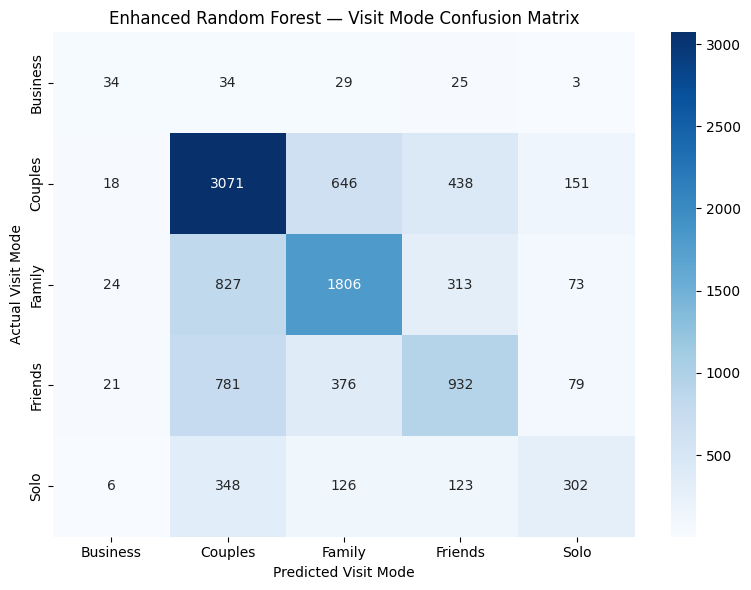

In [61]:
enhanced_cm = confusion_matrix(
    y_test_enhanced,
    enhanced_predictions,
    labels=modes
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    enhanced_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=modes,
    yticklabels=modes
)

plt.title(
    "Enhanced Random Forest — Visit Mode Confusion Matrix"
)

plt.xlabel("Predicted Visit Mode")
plt.ylabel("Actual Visit Mode")

plt.tight_layout()
plt.show()

In [62]:
final_classification_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.364349,
        "Weighted_F1": 0.393934,
        "Macro_F1": 0.290461
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.470716,
        "Weighted_F1": 0.462310,
        "Macro_F1": 0.371799
    },
    {
        "Model": "XGBoost",
        "Accuracy": 0.388721,
        "Weighted_F1": 0.404787,
        "Macro_F1": 0.296542
    },
    {
        "Model": "Enhanced Random Forest",
        "Accuracy": enhanced_accuracy,
        "Weighted_F1": enhanced_f1,
        "Macro_F1": enhanced_macro_f1
    }
])

display(
    final_classification_comparison.sort_values(
        "Macro_F1",
        ascending=False
    )
)

,Model,Accuracy,Weighted_F1,Macro_F1
3,Enhanced Random Forest,0.580484,0.573151,0.482997
1,Random Forest,0.470716,0.462310,0.371799
2,XGBoost,0.388721,0.404787,0.296542
0,Logistic Regression,0.364349,0.393934,0.290461


In [63]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    enhanced_rf,
    "../models/visitmode_classification_model.pkl"
)

print("✅ Final classification model saved.")

✅ Final classification model saved.


In [64]:
classification_classes = [
    "Business",
    "Couples",
    "Family",
    "Friends",
    "Solo"
]

joblib.dump(
    classification_classes,
    "../models/visitmode_classes.pkl"
)

print("✅ Classification classes saved.")

✅ Classification classes saved.


In [65]:
final_classification_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.364349,
        "Weighted_F1": 0.393934,
        "Macro_F1": 0.290461
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.470716,
        "Weighted_F1": 0.462310,
        "Macro_F1": 0.371799
    },
    {
        "Model": "XGBoost",
        "Accuracy": 0.388721,
        "Weighted_F1": 0.404787,
        "Macro_F1": 0.296542
    },
    {
        "Model": "Enhanced Random Forest",
        "Accuracy": enhanced_accuracy,
        "Weighted_F1": enhanced_f1,
        "Macro_F1": enhanced_macro_f1
    }
])

final_classification_results.to_csv(
    "../reports/classification_final_results.csv",
    index=False
)

display(final_classification_results)

,Model,Accuracy,Weighted_F1,Macro_F1
0,Logistic Regression,0.364349,0.393934,0.290461
1,Random Forest,0.470716,0.462310,0.371799
2,XGBoost,0.388721,0.404787,0.296542
3,Enhanced Random Forest,0.580484,0.573151,0.482997


In [66]:
report_dict = classification_report(
    y_test_enhanced,
    enhanced_predictions,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(
    report_dict
).transpose()

classification_report_df.to_csv(
    "../reports/classification_detailed_report.csv"
)

display(classification_report_df)

,precision,recall,f1-score,support
Business,0.330097,0.272000,0.298246,125.000000
Couples,0.606797,0.710222,0.654449,4324.000000
Family,0.605431,0.593493,0.599403,3043.000000
Friends,0.509011,0.425765,0.463682,2189.000000
Solo,0.496711,0.333702,0.399207,905.000000
accuracy,0.580484,0.580484,0.580484,0.580484
macro avg,0.509609,0.467036,0.482997,10586.000000
weighted avg,0.573505,0.580484,0.573151,10586.000000


In [67]:
confusion_df = pd.DataFrame(
    enhanced_cm,
    index=modes,
    columns=modes
)

confusion_df.to_csv(
    "../reports/classification_confusion_matrix.csv"
)

display(confusion_df)

,Business,Couples,Family,Friends,Solo
Business,34,34,29,25,3
Couples,18,3071,646,438,151
Family,24,827,1806,313,73
Friends,21,781,376,932,79
Solo,6,348,126,123,302


In [68]:
model_path = "../models/visitmode_classification_model.pkl"

print(
    "Model exists:",
    os.path.exists(model_path)
)

print(
    "Model size:",
    round(os.path.getsize(model_path) / (1024 * 1024), 2),
    "MB"
)

Model exists: True
Model size: 908.83 MB


In [69]:
loaded_classifier = joblib.load(
    "../models/visitmode_classification_model.pkl"
)

test_predictions_loaded = loaded_classifier.predict(
    X_test_enhanced
)

loaded_accuracy = accuracy_score(
    y_test_enhanced,
    test_predictions_loaded
)

loaded_f1 = f1_score(
    y_test_enhanced,
    test_predictions_loaded,
    average="weighted",
    zero_division=0
)

print("Loaded model accuracy:", round(loaded_accuracy, 4))
print("Loaded model F1      :", round(loaded_f1, 4))

Loaded model accuracy: 0.5805
Loaded model F1      : 0.5732
